# Notebook 1 -- Data Audit and NBS NASS Yield Extraction

**Project:** Crop Yield Prediction Across Nigerian Agroecological Zones  
**Goal of this notebook:** turn the raw Nigerian NBS/NASS Excel report tables into a tidy machine-learning-ready crop-yield table.

## Deliverables from this notebook

- `data/processed/nbs_crop_yield_state_zone_2022_2023.csv`
- basic data-quality summaries
- sanity-check plots for yield, area, and production consistency

## Why this matters

The target variable is **yield in kg/ha**. In agricultural survey tables, yield is often derived from production and harvested area. This means harvested quantity and harvested area are dangerous leakage variables if used naively as predictors. We audit them here, but later notebooks exclude them from the model features.

In [1]:
# Core scientific stack
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Resolve project root whether the notebook is run from /notebooks or from the repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


def print_section(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

# Notebook-aware figure saving -------------------------------------------------
# Every plot generated in this notebook is saved under reports/figures/.
# The counter prevents overwriting plots produced inside loops.
import re

NOTEBOOK_ID = "01_data_audit_and_nbs_parsing"
_FIGURE_SAVE_COUNTER = 1


def _safe_filename(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_") or "figure"


def save_figure(fig, name: str = "figure", dpi: int = 180):
    """Save a matplotlib figure to reports/figures with a notebook-specific name."""
    global _FIGURE_SAVE_COUNTER
    filename = f"{NOTEBOOK_ID}_{_FIGURE_SAVE_COUNTER:02d}_{_safe_filename(name)}.png"
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")
    _FIGURE_SAVE_COUNTER += 1
    return path


## 1.1 Locate the raw NBS workbook

The repository includes the public NBS/NASS 2022/2023 report tables workbook under `data/raw/nbs/`. The parser extracts crop production blocks from the major and minor season sheets.

In [2]:
NBS_XLSX = RAW_DIR / "nbs" / "nass_report_tables_2022_2023.xlsx"
OUTPUT_CSV = PROCESSED_DIR / "nbs_crop_yield_state_zone_2022_2023.csv"

print("Project root:", PROJECT_ROOT)
print("NBS workbook:", NBS_XLSX)
print("Workbook exists:", NBS_XLSX.exists())

if not NBS_XLSX.exists():
    raise FileNotFoundError(
        "NBS workbook not found. Run scripts/00_download_nbs_tables.py or place the workbook under data/raw/nbs/."
    )

Project root: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai-v2
NBS workbook: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai-v2\data\raw\nbs\nass_report_tables_2022_2023.xlsx
Workbook exists: True


## 1.2 Inspecting available Excel sheets

Before we parse any external dataset, we need to always inspect its structure. This makes the processing step easier to debug.

In [3]:
xls = pd.ExcelFile(NBS_XLSX)
sheets = pd.DataFrame({"sheet_index": range(len(xls.sheet_names)), "sheet_name": xls.sheet_names})
display(sheets)

crop_sheets = sheets[sheets["sheet_name"].str.contains("Crop Production2", case=False, na=False)]
print_section("Crop production sheets detected")
display(crop_sheets)

,sheet_index,sheet_name
0,0,Symbols Legend
1,1,HoldingCharacteristic
2,2,Holders & HH members
3,3,Plots_major
4,4,Plots_minor
5,5,Crop Production_major season
6,6,Crop Production_minor season
7,7,Crop Production2_major season
8,8,Crop Production2_minor season
9,9,Fertilizers_pesticides_major



Crop production sheets detected


,sheet_index,sheet_name
7,7,Crop Production2_major season
8,8,Crop Production2_minor season


## 1.3 Previewing one raw crop-production sheet

The NASS workbook contains repeated table blocks, crop headers, zone rows, state rows, and aggregate rows. The parser detects these repeated blocks automatically.

In [4]:
preview_sheet = "Crop Production2_major season"
raw_preview = pd.read_excel(NBS_XLSX, sheet_name=preview_sheet, header=None, nrows=35)
display(raw_preview.head(25))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56
0,Table 1.1: Main 9 crops highly cultivated in a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,CROP 1: MAIZE,NaN,NaN,NaN,NaN,CROP 2: RICE,NaN,NaN,NaN,NaN,CROP 3: CASSAVA,NaN,NaN,NaN,NaN,CROP 4: YAM (4),NaN,NaN,NaN,NaN,CROP 5: SWEET POTATOES,NaN,NaN,NaN,NaN,CROP 6: OKRO,NaN,NaN,NaN,NaN,CROP 7: CHILLIPEPPER(SHOMBO),NaN,NaN,NaN,NaN,CROP 8: TOMATO,NaN,NaN,NaN,NaN,CROP 9: CASHEW,NaN,NaN,NaN,NaN,CROP 10: COCOA,NaN,NaN,NaN,NaN,CROP 11: OIL PALM TREE,NaN,NaN,NaN,NaN
2,Zone,State,Total # of households reporting crop ('000),Planted Area (HA),Harvested Area (HA),Harvested quantity (Kg),Yield (KG/HA),Total # of households reporting crop ('000),Planted Area (HA),Harvested Area (HA),Harvested quantity (Kg),Yield (KG/HA),Total # of households reporting crop (1) ('000),Planted Area (2) (HA),Harvested Area (2) (HA),Harvested quantity (1) (Kg),Yield (3) (KG/HA),Total # of households reporting crop ('000),Planted Area (HA),Harvested Area (HA),Harvested quantity (Kg),Yield (KG/HA),Total # of households reporting crop ('000),Planted Area (HA),Harvested Area (HA),Harvested quantity (Kg),Yield (KG/HA),Total # of households reporting crop ('000),Planted Area (HA),Harvested Area (HA),Harvested quantity (Kg),Yield (KG/HA),Total # of households reporting crop ('000),Planted Area (HA),Harvested Area (HA),Harvested quantity (Kg),Yield (KG/HA),Total # of households reporting crop ('000),Planted Area (HA),Harvested Area (HA),Harvested quantity (Kg),Yield (KG/HA),Total # of households reporting crop (1) ('000),Planted Area (2) (HA),Harvested Area (2) (HA),Harvested quantity (1) (Kg),Yield (3) (KG/HA),Total # of households reporting crop (1) ('000),Planted Area (2) (HA),Harvested Area (2) (HA),Harvested quantity (1) (Kg),Yield (3) (KG/HA),Total # of households reporting crop (1) ('000),Planted Area (2) (HA),Harvested Area (2) (HA),Harvested quantity (1) (Kg),Yield (3) (KG/HA)
3,North Central,Benue,850.39,367795.17127,350398.700331,393992916.635551,1124.413179,863.22,788015.416093,679543.513074,887937176.891804,1306.667137,1502.31,681995.5506,681995.5506,2706755000,4777.568,1526.16,955027.615062,899935.131195,5774600332.36683,6416.685083,252.35,42148.043526,39408.494329,56652837.335794,1437.579342,167.53,40501.721,37981.3567,45841046,1206.9355,142.34,49462.544,47936.6272,80630522,1682.023,184.57,80106.13766,76967.30224,47236760,613.725,31.06,7110.426,7110.426,3080898,(S),0,-,-,-,-,73.08,13854.705396,13854.705396,57145110.761027,2997.950997
4,North Central,Fct,266.34,153246.079216,123737.798835,160617819.178091,1298.049753,70.47,50844.325829,42720.014709,62425516.926462,1461.270961,73.31,44768.1506,44768.1506,113783600,4079.793,93.59,49025.633484,39243.377705,181994802.179468,4637.592705,27.65,6054.749064,4452.361921,11334731.84931,2545.779532,32.65,15133.626,1800.3437,2463971,1368.6117,17.42,9641.5659,3065.5553,15167301,4947.652,11.67,(S),(S),(S),(S),3.14,(S),(S),(S),(S),0.91,(S),(S),(S),(S),1.94,(S),(S),(S),(S)
5,North Central,Kogi,640.86,327793.065371,309235.626289,425714644.828509,1376.667527,139.58,163569.26188,124575.509526,218254059.157975,1751.982071,675.38,263944.7153,263944.7153,1521388000,4690.933,329.23,169342.060256,153063.905833,703516696.522543,4596.228567,48.5,17328.407898,15871.514381,31994724.951615,2015.85836,115.38,31308.842,30825.6974,29633697,961.3309,96.27,22255.6551,20884.8879,35429616,1696.424,63.08,25007.23427,24463.46875,25735980,1052.017,192.21,124870.8,124870.8,56167130,292.8589,0.99,(S),(S),(S),(S),61.13,26515.414821,26515.414821,120350650.053518,4418.702384
6,North Central,Kwara,398.11,307483.872742,301489.864767,500201087.661273,1659.097522,77.02,92255.140997,84485.664693,157305702.1

## 1.4 Parsing the workbook into tidy state × crop × season rows

The parsing lives in `src/nigeria_crop_yield/data/nbs_parser.py` so it can be reused by scripts, tests, and notebooks.

In [5]:
from nigeria_crop_yield.data.nbs_parser import build_nbs_crop_yield_table
from nigeria_crop_yield.data.validation import validate_nbs_table

nbs = build_nbs_crop_yield_table(NBS_XLSX)
validate_nbs_table(nbs)

print_section("Parsed NBS crop-yield table")
print("Rows:", len(nbs))
print("Columns:", len(nbs.columns))
display(nbs.head(10))
display(nbs.tail(10))


Parsed NBS crop-yield table
Rows: 1053
Columns: 12


,season,zone,state,crop,households_reporting_000,planted_area_ha,harvested_area_ha,harvested_quantity_kg,yield_kg_ha,is_aggregate,source_sheet,source_table
0,major,North Central,Benue,MAIZE,850.39,3.677952e+05,3.503987e+05,3.939929e+08,1124.413179,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
1,major,North Central,FCT,MAIZE,266.34,1.532461e+05,1.237378e+05,1.606178e+08,1298.049753,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
2,major,North Central,Kogi,MAIZE,640.86,3.277931e+05,3.092356e+05,4.257146e+08,1376.667527,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
3,major,North Central,Kwara,MAIZE,398.11,3.074839e+05,3.014899e+05,5.002011e+08,1659.097522,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
4,major,North Central,Nasarawa,MAIZE,520.48,4.165471e+05,3.601778e+05,4.213675e+08,1169.887511,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
5,major,North Central,Niger,MAIZE,996.04,1.283121e+06,1.243297e+06,1.467708e+09,1180.496021,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
6,major,North Central,Plateau,MAIZE,1077.79,8.522437e+05,7.499190e+05,9.767935e+08,1302.532050,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
7,major,North Central,Zone Total,MAIZE,4750.01,3.708230e+06,3.438256e+06,4.346395e+09,1264.127772,True,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
8,major,North East,Adamawa,MAIZE,963.37,1.258814e+06,1.015178e+06,1.323914e+09,1304.120312,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
9,major,North East,Bauchi,MAIZE,735.41,7.675438e+05,7.192125e+05,9.698836e+08,1348.535400,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...


,season,zone,state,crop,households_reporting_000,planted_area_ha,harvested_area_ha,harvested_quantity_kg,yield_kg_ha,is_aggregate,source_sheet,source_table
1043,minor,South South,Rivers,WHITEYAM,29.09,5861.231,4473.989,33277450.0,7437.982,False,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."
1044,minor,South South,Zone Total,WHITEYAM,112.64,28201.190,15479.010,88786700.0,5735.942,True,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."
1045,minor,South West,Ekiti,WHITEYAM,46.24,8288.124,1744.418,22461070.0,12875.969,False,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."
1046,minor,South West,Lagos,WHITEYAM,1.25,NaN,NaN,NaN,NaN,False,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."
1047,minor,South West,Ogun,WHITEYAM,3.18,NaN,NaN,NaN,NaN,False,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."
1048,minor,South West,Ondo,WHITEYAM,5.97,NaN,NaN,NaN,NaN,False,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."
1049,minor,South West,Osun,WHITEYAM,17.70,35001.760,28838.580,44138960.0,1530.552,False,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."
1050,minor,South West,Oyo,WHITEYAM,76.51,63174.260,29476.030,121856000.0,4134.071,False,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."
1051,minor,South West,Zone Total,WHITEYAM,150.86,110854.700,61633.460,197828200.0,3209.754,True,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."
1052,minor,Nigeria,Total,WHITEYAM,343.83,187579.500,110380.200,416743900.0,3775.533,True,Crop Production2_minor season,"Table 3: Crops (top 7 crops only), number of a..."


## 1.5 Understanding the columns, types, and missingness in the data

Here, we will find out variables that are complete enough for modeling and which variables need filtering.

In [6]:
print_section("Column types")
display(nbs.dtypes.to_frame("dtype"))

missing = (
    nbs.isna().mean()
    .mul(100)
    .round(2)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("missing_percent", ascending=False)
)
print_section("Missingness by column")
display(missing)

print_section("Numeric summary")
display(nbs.describe(include=[np.number]).T)


Column types


,dtype
season,str
zone,str
state,str
crop,str
households_reporting_000,float64
planted_area_ha,float64
harvested_area_ha,float64
harvested_quantity_kg,float64
yield_kg_ha,float64
is_aggregate,bool



Missingness by column


,column,missing_percent
8,yield_kg_ha,38.46
6,harvested_area_ha,37.32
7,harvested_quantity_kg,36.28
5,planted_area_ha,35.42
4,households_reporting_000,0.19
2,state,0.00
1,zone,0.00
0,season,0.00
3,crop,0.00
9,is_aggregate,0.00



Numeric summary


,count,mean,std,min,25%,50%,75%,max
households_reporting_000,1051.0,3.162816e+02,1.148880e+03,0.0000,2.845000e+00,2.887000e+01,2.034900e+02,2.034285e+04
planted_area_ha,680.0,2.994912e+05,9.526562e+05,119.6533,1.235326e+04,4.838193e+04,1.904416e+05,1.350155e+07
harvested_area_ha,660.0,2.788146e+05,8.733155e+05,318.1117,1.090004e+04,4.378334e+04,1.842828e+05,1.225764e+07
harvested_quantity_kg,671.0,5.087520e+08,1.688047e+09,441211.2000,1.925046e+07,7.882585e+07,3.259371e+08,2.190247e+10
yield_kg_ha,648.0,2.367991e+03,2.261179e+03,194.5162,1.049912e+03,1.547715e+03,2.625285e+03,2.126540e+04


## 1.6 Separating state observations from aggregate rows

The raw NASS sheets include state rows as well as zone/national totals. For supervised learning, aggregate rows can duplicate information and distort validation, so we keep them for audit but exclude them from the modeling dataset.

In [7]:
row_type_summary = (
    nbs.assign(row_type=np.where(nbs["is_aggregate"], "aggregate", "state"))
    .groupby(["season", "row_type"], as_index=False)
    .size()
)
display(row_type_summary)

state_nbs = nbs[~nbs["is_aggregate"].astype(bool)].copy()
state_nbs = state_nbs[state_nbs["yield_kg_ha"].notna()].copy()

print("State-level usable rows:", len(state_nbs))
print("States detected:", state_nbs["state"].nunique())
print("Crops detected:", state_nbs["crop"].nunique())
display(state_nbs.head())

,season,row_type,size
0,major,aggregate,147
1,major,state,598
2,minor,aggregate,49
3,minor,state,259


State-level usable rows: 490
States detected: 37
Crops detected: 22


,season,zone,state,crop,households_reporting_000,planted_area_ha,harvested_area_ha,harvested_quantity_kg,yield_kg_ha,is_aggregate,source_sheet,source_table
0,major,North Central,Benue,MAIZE,850.39,367795.171270,350398.700331,3.939929e+08,1124.413179,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
1,major,North Central,FCT,MAIZE,266.34,153246.079216,123737.798835,1.606178e+08,1298.049753,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
2,major,North Central,Kogi,MAIZE,640.86,327793.065371,309235.626289,4.257146e+08,1376.667527,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
3,major,North Central,Kwara,MAIZE,398.11,307483.872742,301489.864767,5.002011e+08,1659.097522,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...
4,major,North Central,Nasarawa,MAIZE,520.48,416547.122485,360177.787028,4.213675e+08,1169.887511,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...


## 1.7 Coverage by season, crop, and zone

A good ML project should show exactly what the target data covers before training any model, that is my aim here.

In [8]:
season_crop_coverage = (
    state_nbs.groupby(["season", "crop"], as_index=False)
    .agg(
        n_states=("state", "nunique"),
        median_yield_kg_ha=("yield_kg_ha", "median"),
        total_planted_area_ha=("planted_area_ha", "sum"),
    )
    .sort_values(["season", "n_states", "total_planted_area_ha"], ascending=[True, False, False])
)

display(season_crop_coverage.head(25))

zone_coverage = pd.pivot_table(
    state_nbs,
    index="zone",
    columns="season",
    values="state",
    aggfunc="nunique",
    fill_value=0,
)
display(zone_coverage)

,season,crop,n_states,median_yield_kg_ha,total_planted_area_ha
10,major,MAIZE,37,1440.609876,1.350155e+07
4,major,CASSAVA,32,4734.250500,4.723275e+06
13,major,OKRO,32,1292.028350,6.144861e+05
5,major,CHILLI PEPPER(SHOMBO),31,2040.088000,6.684461e+05
16,major,RICE,30,1546.294217,9.738671e+06
20,major,YAM,27,4994.405378,3.640916e+06
18,major,SWEET POTATOES,26,1977.756474,5.075776e+05
19,major,TOMATO,24,1593.764600,7.435244e+05
9,major,GUINEA CORN/SORGHUM,20,1057.202759,8.166373e+06
11,major,MILLET/MAIWA,20,949.553548,6.493007e+06


season,major,minor
zone,,
North Central,7,5
North East,6,6
North West,7,6
South East,5,2
South South,6,4
South West,6,6


## 1.8 Sanity check: reported yield versus computed yield

Yield should approximately equal harvested quantity divided by harvested area. This is a quality-control check only. Later notebooks treat `harvested_quantity_kg` and `harvested_area_ha` as leakage-sensitive columns.


Yield consistency summary


,count,mean,std,min,25%,50%,75%,max
yield_kg_ha,490.0,2433.402346,2396.027869,194.643400,1.059997e+03,1.547715e+03,2719.873841,21265.399000
computed_yield_kg_ha,490.0,2754.142534,3942.602766,217.829773,1.063165e+03,1.548529e+03,2606.340986,48918.665115
yield_abs_diff,490.0,534.197920,2889.997466,0.000000,2.501110e-12,1.500666e-11,0.000254,41211.431115


Saved figure: reports\figures\01_data_audit_and_nbs_parsing_01_figure_01.png


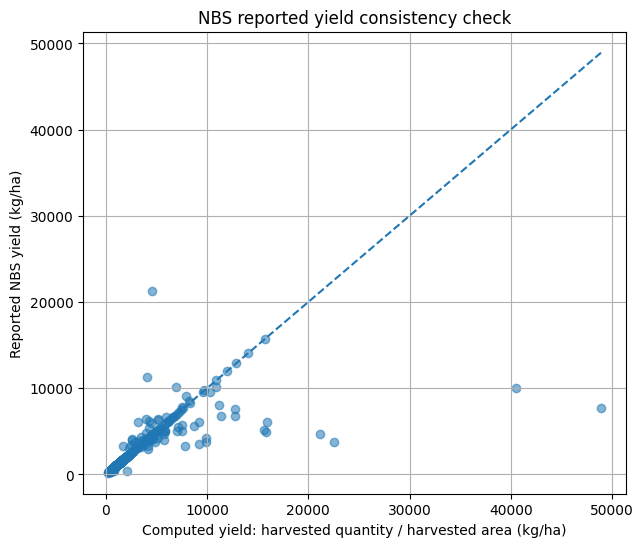

In [9]:
qc = state_nbs.copy()
qc["computed_yield_kg_ha"] = qc["harvested_quantity_kg"] / qc["harvested_area_ha"]
qc["yield_abs_diff"] = (qc["yield_kg_ha"] - qc["computed_yield_kg_ha"]).abs()

print_section("Yield consistency summary")
display(qc[["yield_kg_ha", "computed_yield_kg_ha", "yield_abs_diff"]].describe().T)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(qc["computed_yield_kg_ha"], qc["yield_kg_ha"], alpha=0.55)
lo = np.nanmin([qc["computed_yield_kg_ha"].min(), qc["yield_kg_ha"].min()])
hi = np.nanmax([qc["computed_yield_kg_ha"].max(), qc["yield_kg_ha"].max()])
ax.plot([lo, hi], [lo, hi], linestyle="--")
ax.set_xlabel("Computed yield: harvested quantity / harvested area (kg/ha)")
ax.set_ylabel("Reported NBS yield (kg/ha)")
ax.set_title("NBS reported yield consistency check")
save_figure(fig, "figure_01")
plt.show()

## 1.9 Distribution checks for yield and planted area

Extreme values are not automatically wrong, but they should be visible before modeling.

Saved figure: reports\figures\01_data_audit_and_nbs_parsing_02_figure_02.png


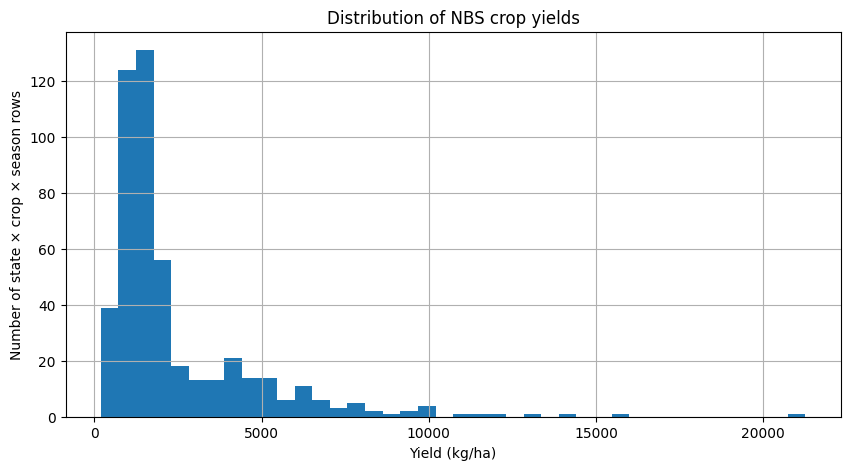

Saved figure: reports\figures\01_data_audit_and_nbs_parsing_03_figure_03.png


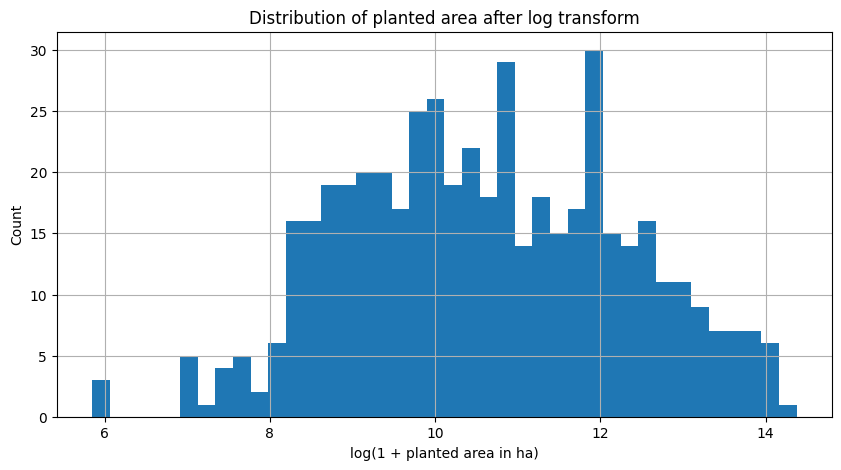

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(state_nbs["yield_kg_ha"].dropna(), bins=40)
ax.set_xlabel("Yield (kg/ha)")
ax.set_ylabel("Number of state × crop × season rows")
ax.set_title("Distribution of NBS crop yields")
save_figure(fig, "figure_02")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(state_nbs["planted_area_ha"].dropna()), bins=40)
ax.set_xlabel("log(1 + planted area in ha)")
ax.set_ylabel("Count")
ax.set_title("Distribution of planted area after log transform")
save_figure(fig, "figure_03")
plt.show()

## 1.10 Saving the processed NBS table

This file becomes the base table used throughout the rest of the project.

In [11]:
nbs.to_csv(OUTPUT_CSV, index=False)
print("Saved:", OUTPUT_CSV)
print("File size KB:", round(OUTPUT_CSV.stat().st_size / 1024, 2))

metadata = {
    "source_workbook": str(NBS_XLSX.relative_to(PROJECT_ROOT)),
    "processed_file": str(OUTPUT_CSV.relative_to(PROJECT_ROOT)),
    "n_rows": int(len(nbs)),
    "n_state_level_rows_with_yield": int(len(state_nbs)),
    "n_crops": int(state_nbs["crop"].nunique()),
    "n_states": int(state_nbs["state"].nunique()),
    "target": "yield_kg_ha",
}
metadata_path = PROCESSED_DIR / "dataset_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2))
print("Saved metadata:", metadata_path)

Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai-v2\data\processed\nbs_crop_yield_state_zone_2022_2023.csv
File size KB: 347.86
Saved metadata: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai-v2\data\processed\dataset_metadata.json
